# Fit clustering for motivational state

## General imports

In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

## Importing custom functions from different folder:

In [ ]:
# Get the current directory
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
folder = 'Implementation'
data_folder = os.path.join(parent_dir, folder)

# Construct the full file path
file_ = 'utils_data'
full_path = os.path.join(data_folder, file_)
print(full_path)
print(data_folder)
sys.path.append(data_folder)  

# Load the functions from .py file  
try:
    from utils_data_multiple import load_multiple_data, plot_multiple_data, point_to_segment, cleaning_clustering_multiple_data
    from utils_data_multiple import plot_data
    from utils_data_multiple import saving_processed_mult_data, load_processed_mult_data, multiple_linear_transf  
    
    from utils_data_multiple import get_cluster_data, get_cluster_idxrule
    from utils_model_multiple import numericalSimulation, plot_trajectory
    
    from utils_model_multiple import load_params, fitParamaters_mult
    from utils_model_multiple import plotting_dict_params, combined_multiple_trajectories_plot
    
    
    from utils_model_multiple import dict_to_array
    #from utils_model import plot_multiple_trajectories_combined
    from utils_model import  fitParamaters
    
    from utils_data import processing_data, load_processed_data, saving_processed_data
    #from utils_data import plot_velocity
    #from utils_model_multiple import numericalSimulation, ComputeFunctional, ComputeVel
    #from utils_model_multiple import generate_trajectory, plot_simulation, generate_trajectory_vel, optimize_Sigma, plot_multiple_trajectories, plotting_params
except ModuleNotFoundError as e:
    print("ModuleNotFoundError:", e)

c:\Users\Flavia\Documents\Flavia Python codes\MotorControlPrediction\Implementation\utils_data
c:\Users\Flavia\Documents\Flavia Python codes\MotorControlPrediction\Implementation


## Treating different motivational levels

Motivation may be: 
- 0: playing alone
- 1: easy rival
- 2: hard rival 

The data is now clustered by motivation level, i.e. `dataTrajecetories-25-M1-C1`. We are also splitting the dataset depending on the playing modes: passing through and stopping. For each dataset moreover we have the four different trajectories.

The data is normalized, clustered in terms of motivation, playing mode and ordered by trajectory. 

We are interested in having two different groups of fitted models:
1. First just clustered by subject, with all the motivational levels (and in fact all the modes) as if they were just one. This has already been done, when fitting the model for each subject, and getting the parameters. The only thing we are meeting seems to be an accuracy metrics to compare the results with the following group of fits.
2. Then we want to consider different fits for each subject and each motivational level. Here we will get 3 fits for each subject. 

Hence, we get a total of 4 sets of fitted parameters for each subject that we should study how to compare. 

## Setting the parameters for the code implementation

Set the following parameters according to the study you wish to conduct: 
- `processing` when set to `True` it conducts the whole processing process from the raw data. This includes: 
    - `cleaning_clustering_multiple_data`: 
        - Cleaning the trajectories which do not cross the target and truncating the ones which do cross it. Also storing the optimal time in which they reach the target, $T^*$, stored in `idxrule` 
        - Classifying the data in 4 clusters, depending on the target they cross
    - `multiple_linear_transf`: 
        - Rotating the needed trajectories and scaling them in order to get normalized data
        - Computing the mean velocity and the velocity profiles for each trajectory

ATTENTION: This process takes more than 2 hours to be fully completed. 

- `fitting` when set to `True` the fitting of the parameters is conducted with the already processed data. This includes: 
    - `fitParamaters_mult`: 
        - Sequential approach: 
            1. Optimal movement duration: Generate the optimal trajectory by optimizing the Functional in terms of the time T 
            2. Optimal controller: generate the optimal trajectory with the optimal time duration by minimizing the functional in terms of the biomechanical parameters $(\alpha, \gamma, \varepsilon)$. 
            3. Stochastic optimization: generate the optimal trajectory with optimal time duration and biomechanical parameters by optimizing the Kolmogorov Sirnov estimate in terms of the sigma 
        - Saving the obtained parameters

- `plotting` when set to `True` all the trajectory plots and prints are explicitly shown on this Notebook
- `saving` when set to `True` all the plots and data processed is saved. 

In [3]:
processing = False
fitting = False
plotting = False
saving = False

## Loading multiple data

In [4]:
cluster_points = [
        (10.5, 4.85),   # pt2
        (-11, -5),       # pt3  
        (10.5, 0),      # pt1    
        (-10.5, 1.25)  # pt0
    ]
n_clusters = 4

segments = point_to_segment(cluster_points, n_clusters)

In [5]:
if processing:
    print('Loading and processing data...')
    data_dict = load_multiple_data(first_subj = 25, last_subj = 37, 
                       file_names = 'dataTrajectories' )
    if plotting: 
        print('List with al the target segments:', segments)
        print('List with the two points of segment for cluster 0:', segments[0])
        print('Array with point target 1 for cluster 0:', segments[0][0])
        print('First coordinate of point target 1 for cluster 0:', segments[0][0][0])
        plot_multiple_data(data_dict)
    
    cleaned_data_dict, idxrule_dict = cleaning_clustering_multiple_data(data_dict, 
                                    segments, 
                                    first_subj = 25, last_subj = 37,
                                    save_dir = 'subject_plots')

    if saving: 
        saving_processed_mult_data(idxrule_dict=idxrule_dict, folder_name='clustered_multiple_data')
        saving_processed_mult_data(cleaned_data_dict = cleaned_data_dict, 
                                folder_name = 'clustered_multiple_data')
        
    scaled_data_dict, velocity_dict, results_dict = multiple_linear_transf(cleaned_data_dict, idxrule_dict, 
                            segments, 
                            first_subj = 25, last_subj = 37,
                            n_clusters = 4,
                            saving = True, 
                            save_dir = 'subject_plots_2')
    if saving: 
        saving_processed_mult_data(cleaned_data_dict = scaled_data_dict, 
                                folder_name = 'scaled_data')
        saving_processed_mult_data(cleaned_data_dict = velocity_dict, 
                                folder_name = 'velocity')
        saving_processed_mult_data(idxrule_dict = results_dict, 
                                folder_name = 'scaled_data')
        
    print('Fitting paramaters for the optimized trajectory...')   
    
    if fitting: 
        new_params, opt_sigma = fitParamaters_mult(scaled_data_dict,
                    idxrule_dict, 
                    results_dict,
                    segments, 
                    first_subj = 25, last_subj = 30,
                    n_clusters = 4, folder_name = 'fitted_trajectories_2', 
                    saving = saving)
    
elif fitting: 
    print('Loading processed data...')
    cleaned_data_dict, idxrule_dict = load_processed_mult_data(folder_name='clustered_multiple_data')
    scaled_data_dict, results_dict = load_processed_mult_data(folder_name='scaled_multiple_data') 
    print('Data loaded and processed :)')
    
    print('Fitting paramaters for the optimized trajectory...')   
    new_params, opt_sigma = fitParamaters_mult(scaled_data_dict,
                  idxrule_dict, 
                  results_dict,
                  segments, 
                  first_subj = 25, last_subj = 30,
                  n_clusters = 4, folder_name = 'fitted_trajectories_2', 
                  saving = saving)
    
else: 
    print('Loading fitted parameters...')
    params_loaded = load_params(folder_name = 'fitted_parameters')
    opt_sigma = load_params(folder_name = 'fitted_parameters_sigma')

Loading fitted parameters...
Loading the new parameters...
New parameters have been loaded successfully.
Loading the new parameters...
New parameters have been loaded successfully.


### Parameter study for all the subjects together clustered by chosen target, motivational level, mode

$\gamma (s^{-1})$
T-test results:  TtestResult(statistic=np.float64(-13.027006863757283), pvalue=np.float64(2.445960718896802e-29), df=np.float64(227.0))
$\gamma (s^{-1})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.9344425295999274), pvalue=np.float64(8.867954929096948e-10))
$\varepsilon (m^{-1} kg^{-2} s^{4})$
T-test results:  TtestResult(statistic=np.float64(-4.501598487361628), pvalue=np.float64(1.0780131371863085e-05), df=np.float64(227.0))
$\varepsilon (m^{-1} kg^{-2} s^{4})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.963435802187626), pvalue=np.float64(1.6470376665480798e-06))
$\alpha (kg^{-1})$
T-test results:  TtestResult(statistic=np.float64(-14.185414014232984), pvalue=np.float64(3.975377753606876e-33), df=np.float64(227.0))
$\alpha (kg^{-1})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.9266096174032474), pvalue=np.float64(1.6787794438234304e-10))
$\sigma$
T-test results:  TtestResult(statistic=np.float64(5.3290435

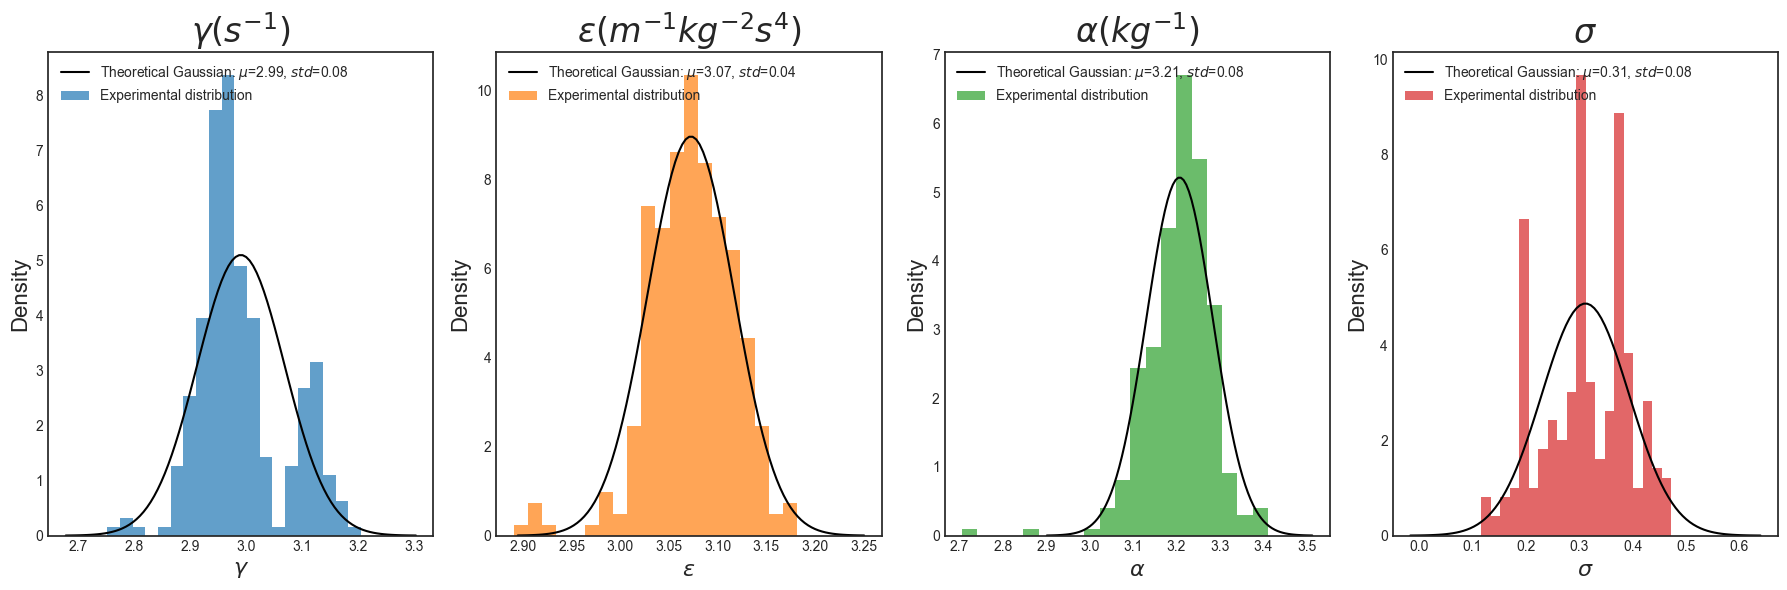

([TtestResult(statistic=np.float64(-13.027006863757283), pvalue=np.float64(2.445960718896802e-29), df=np.float64(227.0)),
  TtestResult(statistic=np.float64(-4.501598487361628), pvalue=np.float64(1.0780131371863085e-05), df=np.float64(227.0)),
  TtestResult(statistic=np.float64(-14.185414014232984), pvalue=np.float64(3.975377753606876e-33), df=np.float64(227.0)),
  TtestResult(statistic=np.float64(5.329043578778999), pvalue=np.float64(2.3767986177548851e-07), df=np.float64(227.0))],
 [ShapiroResult(statistic=np.float64(0.9344425295999274), pvalue=np.float64(8.867954929096948e-10)),
  ShapiroResult(statistic=np.float64(0.963435802187626), pvalue=np.float64(1.6470376665480798e-06)),
  ShapiroResult(statistic=np.float64(0.9266096174032474), pvalue=np.float64(1.6787794438234304e-10)),
  ShapiroResult(statistic=np.float64(0.9652554475199686), pvalue=np.float64(2.9190218212445577e-06))],
 [np.float64(2.9912293639933956),
  np.float64(3.0726262678275704),
  np.float64(3.207184624707192),
  np

In [6]:
plotting_dict_params(params_dict = params_loaded, opt_sigma = opt_sigma, 
                         barWidth=0.5, plotting_ = 1,
                         saving_plot = True, folder_name = 'fitted_pics', 
                         pic_name = 'parameters_gaussians_5')

### Computing accuracy metrics for different parameter combinations

In [7]:
cleaned_data_dict, idxrule_dict = load_processed_mult_data(folder_name='clustered_multiple_data')

Loading the cleaned data...
CSV and idxrule JSON files have been loaded successfully.


The function `combined_multiple_trajectories_plot` plots the trajectories for a given set of subjects, for each motivation level and mode. It also returns the set of metrics (`'MSE', 'RMSE', 'DTW', 'MAE'`), for each set of fitted parameters, this is, for each cluster (depending on the chosen target, so 4 clusters) for each motivational level (3 motivational levels) and for each mode (2 modes) = 24 sets of parameters. 

We would like to have one set of parameters per subject first, and compute the accuracy metrics instead. 

Simulated and experimental trajectories for subject  25


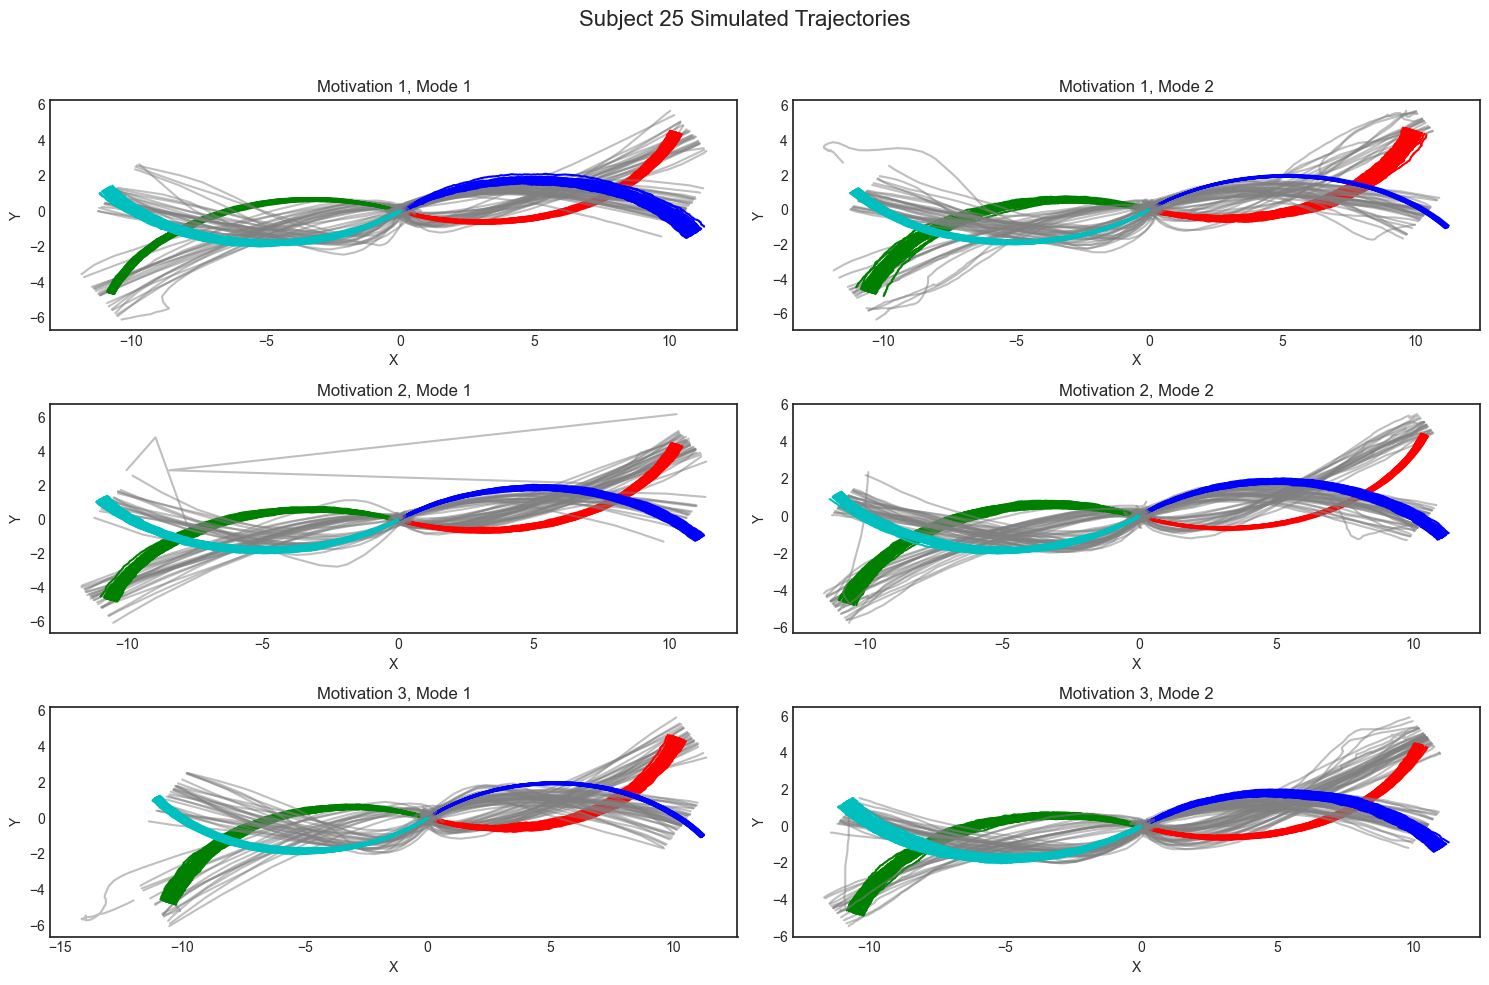

In [13]:
metrics_dict = combined_multiple_trajectories_plot(scaled_data_dict = cleaned_data_dict, 
                                    params_loaded = params_loaded, 
                                    opt_sigma = opt_sigma, 
                                    segments = segments,
                                    first_subj = 25, last_subj = 26,
                                    n_clusters = 4,
                                    n = 75, 
                                    saving = False, 
                                    inverse = True, 
                                    save_dir = 'project_plots', 
                                    picname = 'Simulated_trajectories_25_acc', 
                                    metrics = True)

In [20]:
print(metrics_dict.keys())
print(len(metrics_dict[25].keys()))
print(metrics_dict[25].keys())
print('Metrics for the first cluster:', metrics_dict[25]['25_11_cluster_0'])  
#metrics_dict

dict_keys([25])
24
dict_keys(['25_11_cluster_0', '25_11_cluster_1', '25_11_cluster_2', '25_11_cluster_3', '25_12_cluster_0', '25_12_cluster_1', '25_12_cluster_2', '25_12_cluster_3', '25_21_cluster_0', '25_21_cluster_1', '25_21_cluster_2', '25_21_cluster_3', '25_22_cluster_0', '25_22_cluster_1', '25_22_cluster_2', '25_22_cluster_3', '25_31_cluster_0', '25_31_cluster_1', '25_31_cluster_2', '25_31_cluster_3', '25_32_cluster_0', '25_32_cluster_1', '25_32_cluster_2', '25_32_cluster_3'])
Metrics for the first cluster:                                          0
0  (23.98457211982994, 1.4830903910434625)
1   (4.897404631009158, 1.217821986598806)
2   (128.5919024341145, 33.97998289481149)
3  (3.656274801320209, 0.7533629979658145)


In [23]:
print(params_loaded.keys())
print(params_loaded[25].keys())

dict_keys([25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36])
dict_keys(['25_11_cluster_0', '25_11_cluster_1', '25_11_cluster_2', '25_11_cluster_3', '25_12_cluster_0', '25_12_cluster_1', '25_12_cluster_2', '25_12_cluster_3', '25_21_cluster_0', '25_21_cluster_1', '25_21_cluster_2', '25_21_cluster_3', '25_22_cluster_0', '25_22_cluster_1', '25_22_cluster_2', '25_22_cluster_3', '25_31_cluster_0', '25_31_cluster_1', '25_31_cluster_2', '25_31_cluster_3', '25_32_cluster_0', '25_32_cluster_1', '25_32_cluster_2', '25_32_cluster_3'])


### Functions for computing the metrics

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from dtaidistance import dtw

def compute_mse_between_averages(dfx: pd.DataFrame, dfy: pd.DataFrame, x_sim: np.ndarray, y_sim: np.ndarray, 
                                 error = 'MSE'):
    avg_x_exp = dfx.mean(axis=0)
    avg_y_exp = dfy.mean(axis=0)
    
    avg_x_sim = np.nanmean(x_sim, axis=0)
    avg_y_sim = np.nanmean(y_sim, axis=0)

    # Truncate or pad the experimental averages to match the simulated length
    if len(avg_x_exp) > len(avg_x_sim):
        avg_x_exp = avg_x_exp[:len(avg_x_sim)]
        avg_y_exp = avg_y_exp[:len(avg_y_sim)]
    else:
        avg_x_exp = np.pad(avg_x_exp, (0, len(avg_x_sim) - len(avg_x_exp)), 'constant', constant_values=np.nan)
        avg_y_exp = np.pad(avg_y_exp, (0, len(avg_y_sim) - len(avg_y_exp)), 'constant', constant_values=np.nan)
    
    if error == 'MSE':
        mse_x = mean_squared_error(avg_x_exp, avg_x_sim)
        mse_y = mean_squared_error(avg_y_exp, avg_y_sim)
    elif error == 'RMSE': 
        mse_x = np.sqrt(mean_squared_error(avg_x_exp, avg_x_sim))
        mse_y = np.sqrt(mean_squared_error(avg_y_exp, avg_y_sim))
    elif error == 'DTW': 
        mse_x = dtw.distance(avg_x_exp, avg_x_sim)
        mse_y = dtw.distance(avg_y_exp, avg_y_sim) 
    else:
        mse_x = mean_absolute_error(avg_x_exp, avg_x_sim)
        mse_y = mean_absolute_error(avg_y_exp, avg_y_sim) 
        
    return mse_x, mse_y

def pad_trajectories(trajectories):
    max_length = max(len(t) for t in trajectories)
    padded_trajectories = np.array([np.pad(t, (0, max_length - len(t)), 'constant', constant_values=np.nan) for t in trajectories])
    return padded_trajectories

def pad_or_truncate_trajectories(trajectories, target_length):
    return np.array([np.pad(t, (0, max(0, target_length - len(t))), 'constant', constant_values=np.nan)[:target_length] for t in trajectories])



In [10]:
from typing import Tuple, List, Dict
import math

def linear_transf_(dfx : pd.DataFrame, dfy : pd.DataFrame, 
                  rectx : np.ndarray, recty : np.ndarray, 
                  inverse = False) -> Tuple[pd.DataFrame, pd.DataFrame]:
    
    
    if inverse:
        
        if rectx[0] > 0 and recty[-1] > 0:
            model_origin = np.array((0.5,0.2))
            screen_origin = np.array(((rectx[1]+rectx[0])/2,(recty[1]+recty[0])/2))
            model_target = np.array((np.cos(-math.pi*12/24),np.sin(-math.pi*12/24))) 

        elif rectx[0] < 0 and recty[-1] > 0: 
            model_origin = np.array((0.8,-0.8))
            screen_origin = np.array(((-rectx[1]-rectx[0])/2,(recty[1]+recty[0])/2))
            model_target = np.array((np.cos(-math.pi*12/24),np.sin(-math.pi*12/24))) 
            
        elif rectx[0] > 0 and recty[-1] < 0:
            model_origin = np.array((0.9,-0.8))
            screen_origin = np.array(((rectx[1]+rectx[0])/2,(-recty[1]-recty[0])/2)) 
            model_target = np.array((np.cos(-math.pi*12/24),np.sin(-math.pi*12/24))) 
            
        else: 
            model_origin = np.array((0.5,0.2))
            screen_origin = np.array(((-rectx[1]-rectx[0])/2,(-recty[1]-recty[0])/2))
            model_target = np.array((np.cos(-math.pi*12/24),np.sin(-math.pi*12/24))) 
    
        screen_target = np.array((0,0)) 
        
    else:
    
        if rectx[0] > 0 and recty[-1] > 0:
            model_target = np.array((0.5,1))
            screen_target = np.array(((rectx[1]+rectx[0])/2,(recty[1]+recty[0])/2))
            model_origin = np.array((np.cos(-math.pi*12/24),np.sin(-math.pi*12/24))) 

        elif rectx[0] < 0 and recty[-1] > 0: 
            model_target = np.array((1.5,0))
            dfx = -1 * dfx
            screen_target = np.array(((-rectx[1]-rectx[0])/2,(recty[1]+recty[0])/2))
            model_origin = np.array((np.cos(-math.pi*12/24),np.sin(-math.pi*12/24))) 
            
        elif rectx[0] > 0 and recty[-1] < 0:
            model_target = np.array((1.5,0))
            screen_target = np.array(((rectx[1]+rectx[0])/2,(-recty[1]-recty[0])/2)) 
            model_origin = np.array((np.cos(-math.pi*12/24),np.sin(-math.pi*12/24))) 
            
        else: 
            model_target = np.array((0.5,1))
            screen_target = np.array(((-rectx[1]-rectx[0])/2,(-recty[1]-recty[0])/2))
            model_origin = np.array((np.cos(-math.pi*12/24),np.sin(-math.pi*12/24))) 
    
        screen_origin = np.array((0,0))

    v_model=model_target-model_origin
    v_model_ort=np.array((v_model[1],-v_model[0]))

    v_screen=screen_target-screen_origin
    v_screen_ort=np.array((v_screen[1],-v_screen[0]))

    model_M=np.vstack((np.append(model_origin,1),np.append(model_target,1),np.append(v_model_ort,0))).T
    screen_M=np.vstack((np.append(screen_origin,1),np.append(screen_target,1),np.append(v_screen_ort,0))).T

    M=np.dot(model_M,np.linalg.inv(screen_M))
    A=M[:2,:2]
    b=M[:2,-1:].flatten()
    
    if inverse: 
        # Compute the inverse of the affine transformation
        A= np.linalg.inv(A)
        b = -np.dot(A, b)
    
    dfx_=A[0,0]*dfx+A[0,1]*dfy+b[0]
    dfy_=A[1,0]*dfx+A[1,1]*dfy+b[1]
    
    if inverse: 
        if rectx[0] > 0 and recty[-1] > 0:
            return dfx_, dfy_
        elif rectx[0] < 0 and recty[-1] > 0: 
            dfx_ = -1 * dfx_
            return dfx_, dfy_
        elif rectx[0] > 0 and recty[-1] < 0:
            dfy_ = -1 * dfy_
            return dfx_, dfy_
        else: 
            dfx_ = -1 * dfx_
            dfy_ = -1 * dfy_
            return dfx_, dfy_
    
    else: 
        return dfx_, dfy_

In [11]:
def plot_multiple_trajectories(dfx: pd.DataFrame, dfy: pd.DataFrame,
                               new_params: np.ndarray, opt_Sigma: np.float64,  
                               motivation: int, mode : int, cluster : int,
                               segments : List[Tuple[Tuple[float, float], Tuple[float, float]]],
                               parameters2=(3.7, -0.15679707,  0.97252444,  0.54660283, -6.75775885, -0.06253371),
                               n=50, timestep=1/500, pic_name ='Simulated_Trajectories', 
                               folder_name = 'project_plots',
                               ax=None, saving_plot=False, color = 'blue', inverse = False, 
                               metrics = False): 
    
    if ax is None:
        fig, ax = plt.subplots()
    
    if metrics: 
        metrics_results = {}
        
    ## Plotting experimental data
    for i in range(len(dfx)):
        ax.plot(dfx.iloc[i], dfy.iloc[i], color='gray', alpha=0.5, label='Experimental Trajectories' if i == 0 and cluster == 0 else "")
       
                        
    ## Plotting numerical simulation
    gamma, epsilon, alpha = new_params.x
    sigma = opt_Sigma.x
    
    simulated_x = []
    simulated_y = []
    
    for i in range(n):
        x, y, v, w, ux, uy, T = numericalSimulation(x_0=(0,0,0,0), p_T=1.3, 
                                                     sigma=sigma*0.05, gamma=gamma, epsilon=epsilon, alpha=alpha,
                                                     u_0=parameters2[:2], l_0=parameters2[2:], 
                                                     i_max=1000, dt=timestep,
                                                     Autoregr=False, 
                                                     Arc=True, angle=math.pi*12/24, angle0=0, p=(.2,0), r=.1)
        if inverse: 
            x, y = linear_transf_(x, y, segments[cluster][0], segments[cluster][1], inverse = True)
            ax.plot(x, y, color = color, label=f'Simulated Trajectories Cluster {cluster}' if i == 0 else "") 
        else:
            ax.plot(x, y, color = color, label=f'Simulated Trajectories Cluster {cluster}' if i == 0 else "") 
        simulated_x.append(x)
        simulated_y.append(y)
                
    
    if metrics: 
        simulated_x = pad_trajectories(simulated_x)
        simulated_y = pad_trajectories(simulated_y)

        dfx_padded = pad_or_truncate_trajectories(dfx.values, simulated_x.shape[1])
        dfy_padded = pad_or_truncate_trajectories(dfy.values, simulated_y.shape[1])
        
        metrics_label = ['MSE', 'RMSE', 'DTW', 'MAE']
        metrics_res = []
        for metric in metrics_label:
            mse_avg_x, mse_avg_y = compute_mse_between_averages(dfx_padded, dfy_padded, simulated_x, simulated_y, error = metric)
        
            #metrics_res.append({metric : (mse_avg_x, mse_avg_y)})
            metrics_res.append((mse_avg_x, mse_avg_y))
        
        metrics_results[cluster] = metrics_res
    
    ax.set_title(f'Motivation {motivation}, Mode {mode}')
    #ax.grid(True)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    #ax.legend()
    
    if saving_plot:
        # Check if the 'pics' folder exists, if not, create it
        if not os.path.exists(folder_name):
            os.makedirs(folder_name)
        # Save the figure with a specific name based on the cluster
        filename = f'{pic_name}{motivation}{mode}.png'
        filepath = os.path.join(folder_name, filename)
        plt.savefig(filepath)
    
    if ax is None:
        plt.show()
        
    if metrics:
        return pd.DataFrame(metrics_results)
    else: 
        return x, y

In [12]:
def combined_multiple_trajectories_plot(scaled_data_dict: dict, 
                                        params_loaded: dict, 
                                        opt_sigma : dict, 
                                        segments : List[Tuple[Tuple[float, float], Tuple[float, float]]],
                                        first_subj: int = 25, last_subj: int = 37,
                                        n_clusters = 4, 
                                        n = 50, 
                                        saving = True, 
                                        inverse = True, 
                                        save_dir: str = 'project_plots', 
                                        picname: str = 'Simulated_trajectories', 
                                        metrics = False): 
    
    colors = ['r', 'g', 'b', 'c']
        
    if metrics: 
        metrics_dict = {}
    
    for subject in range(first_subj, last_subj):
        
        print('Simulated and experimental trajectories for subject ', subject )
        fig, axes = plt.subplots(3, 2, figsize=(15, 10))  # 3 rows, 2 columns of subplots
        fig.suptitle(f'Subject {subject} Simulated Trajectories', fontsize=16)
        subplot_index = 0
        pic_name = f'{picname}_{subject}'
        
        for motivation in range(1, 4):
            
            for mode in range(1, 3):
                #print(f'Simulated and experimental trajectories for subject {subject}, motivation {motivation} and mode {mode}')
        
                ax = axes[subplot_index // 2, subplot_index % 2]
                
                for cluster in range(n_clusters):
                      
                    key_x = f'dfx_{subject}_{motivation}{mode}_cluster_{cluster}'
                    key_y = f'dfy_{subject}_{motivation}{mode}_cluster_{cluster}'
                    key_ = f'{subject}_{motivation}{mode}_cluster_{cluster}' 
                    
                    # Retrieve data if available
                    dfx_ = scaled_data_dict[subject].get(key_x)
                    dfy_ = scaled_data_dict[subject].get(key_y)
                    params = params_loaded[subject].get(key_)
                    sigma = opt_sigma[subject].get(key_)
                    
                    # Plotting the experimental data
                    color = colors[cluster % len(colors)]
                        
                            
                    # Plotting the simulated data
                    if params is not None and sigma is not None:
                        try:
                            metrics_df = plot_multiple_trajectories(dfx = dfx_, dfy = dfy_,
                                                                new_params = params, opt_Sigma = sigma,  
                                                                motivation = motivation, mode = mode, cluster = cluster,
                                                                segments = segments,
                                                                parameters2=(3.7, -0.15679707,  0.97252444,  0.54660283, -6.75775885, -0.06253371),
                                                                n=n, timestep=1/500, pic_name = picname, 
                                                                folder_name = save_dir,
                                                                ax=ax, saving_plot=False, color = color, inverse = inverse, metrics = metrics)
                        except ValueError as e:
                            print(f"Skipping cluster {cluster} for subject {subject}, motivation {motivation}, mode {mode}: {e}")
                
                    if metrics: 
                        if subject not in metrics_dict:
                            metrics_dict[subject] = {}
                        metrics_dict[subject][key_] = metrics_df
                
                subplot_index += 1
                
        fig.tight_layout(rect=[0, 0, 1, 0.96])  
        
        if saving:
            if not os.path.exists(saving):
                os.makedirs(saving)
            filename = f'{pic_name}.png'
            filepath = os.path.join(save_dir, filename)
            plt.savefig(filepath)
            plt.close(fig)  

    plt.show()
    
    return metrics_dict


In [27]:
def plot_multiple_trajectories_combined_(dfx: pd.DataFrame, dfy: pd.DataFrame,
                                         n_clusters: int, new_params: np.ndarray, opt_Sigma: np.float64,
                                         results: pd.DataFrame,
                                         parameters2=(3.7, -0.15679707, 0.97252444, 0.54660283, -6.75775885, -0.06253371),
                                         subject=25,
                                         n=50, timestep=1/500,
                                         pic_name='Trajectories_combined', pic_folder='project_plots',
                                         saving_plot=False,
                                         inverse=False, 
                                         metrics=True, 
                                         plotting_vel = True):

    if plotting_vel: 
        fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 16))
        ax2.set_title(f'Subject {subject} Simulated Velocity', fontsize=16)
        
    else: 
        fig, ax = plt.subplots(figsize=(10, 8))
        
    ax.set_title(f'Subject {subject} Simulated Trajectories', fontsize=16)
    colors = ['r', 'g', 'b', 'c']
    
    metrics_results = {}

    for cluster in range(n_clusters):

        rectx_list = results.rectx[cluster].replace(']', ' ')
        rectx_list = rectx_list.replace('[', ' ')
        rectx_list = rectx_list.split()
        rectx = np.array(rectx_list, dtype=float)

        recty_list = results.recty[cluster].replace(']', ' ')
        recty_list = recty_list.replace('[', ' ')
        recty_list = recty_list.split()
        recty = np.array(recty_list, dtype=float)

        # Plotting experimental data
        if inverse:
            dfx_, dfy_ = linear_transf_(dfx[cluster], dfy[cluster], rectx, recty, inverse=True)
            for i in range(len(dfx[cluster])):
                ax.plot(dfx_.iloc[i], dfy_.iloc[i], color='gray', alpha=0.5, label='Experimental Trajectories' if i == 0 and cluster == 0 else "")
        else:
            for i in range(len(dfx[cluster])):
                ax.plot(dfx[cluster].iloc[i], dfy[cluster].iloc[i], color='gray', alpha=0.5, label='Experimental Trajectories' if i == 0 else "")

        # Plotting numerical simulation
        gamma, epsilon, alpha = new_params[cluster]
        sigma = opt_Sigma[cluster]

        simulated_x = []
        simulated_y = []
        t_ = []

        for i in range(n):
            x, y, v, w, ux, uy, T = numericalSimulation(x_0=(0, 0, 0, 0), p_T=1.0,
                                                        sigma=sigma, gamma=gamma, epsilon=epsilon, alpha=alpha,
                                                        u_0=parameters2[:2], l_0=parameters2[2:],
                                                        i_max=1000, dt=timestep,
                                                        Autoregr=False,
                                                        Arc=True, angle=math.pi*7/24, angle0=0, p=(.2, 0), r=.1)
            t_.append(T)
            if plotting_vel: 
                dfv=np.sqrt(np.square(v)+np.square(w))
                ax2.plot(dfv, color=colors[cluster], label=f'Simulated Velocity Cluster {cluster}' if i == 0 else "") 
                 
                #ax2.plot(v, w, color=colors[cluster], label=f'Simulated Velocity Cluster {cluster}' if i == 0 else "") 
                
            if inverse:
                x_, y_ = linear_transf_(x, y, rectx, recty, inverse=True)
                simulated_x.append(x_)
                simulated_y.append(y_)
                ax.plot(x_, y_, color=colors[cluster], label=f'Simulated Trajectories Cluster {cluster}' if i == 0 else "")
            else:
                simulated_x.append(x)
                simulated_y.append(y)
                ax.plot(x, y, color=colors[cluster], label=f'Simulated Trajectories Cluster {cluster}' if i == 0 else "")
        
        if metrics:
            if cluster not in metrics_results:
                metrics_results[cluster] = {}
            # Padding trajectories to the same length
            simulated_x = pad_trajectories(simulated_x)
            simulated_y = pad_trajectories(simulated_y)

            dfx_padded = pad_or_truncate_trajectories(dfx[cluster].values, simulated_x.shape[1])
            dfy_padded = pad_or_truncate_trajectories(dfy[cluster].values, simulated_y.shape[1])

            metrics = ['MSE', 'RMSE', 'DTW', 'MAE']
            metrics_res = []
            for metric in metrics:
                mse_avg_x, mse_avg_y = compute_mse_between_averages(dfx_padded, dfy_padded, simulated_x, simulated_y, error = metric)
            
                #metrics_res.append({metric : (mse_avg_x, mse_avg_y)})
                metrics_res.append((mse_avg_x, mse_avg_y))
            metrics_res.append(t_)
            metrics_results[cluster] = metrics_res
            
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend()
    
    if plotting_vel: 
        ax2.set_xlabel('Velocity x axis')
        ax2.set_ylabel('Velocity y axis')
        ax2.legend()
        fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    else: 
        fig.tight_layout()

    if saving_plot:
        if not os.path.exists(pic_folder):
            os.makedirs(pic_folder)
        filename = f'{pic_name}.png'
        filepath = os.path.join(pic_folder, filename)
        plt.savefig(filepath)

    plt.show()

    
    if metrics:
        return pd.DataFrame(metrics_results)

### Mean of the metrics per subject (or per set of paramaters)

In [ ]:
def compute_means_single_df(df):
    means_list = []
    
    for i in range(4): 
        x_mean = 0
        y_mean = 0 
        
        for key in df.keys():
            dff = df[key]
            x_mean += dff[int(key[-1])][i][0]
            y_mean += dff[int(key[-1])][i][1]
        x_mean = x_mean / len(df.keys())
        y_mean = y_mean / len(df.keys())
        means_list.append((x_mean, y_mean)) 
    
    return means_list

# Example usage of compute_means_single_df: 
means_list = compute_means_single_df(metrics_dict[25])
means_list

[(24.446699302400166, 1.4655699222140568),
 (np.float64(4.942062832475897), np.float64(1.2083799323977247)),
 (131.6521299224435, 31.219262109884042),
 (3.6689247689966105, 0.8577566971726304)]

The function `compute_means_single_df` computes the mean coordinates for each cluster across all subjects in a single DataFrame. In this case, it computes the means of the metrics (the 4 metrics: `MSE, RMSE, DTW, MAE`) for each desired subject, among the 4 clusters, motivational levels and modes. Hence, we get the mean of the metrics between the estimated trajectories for each cluster, motivational level, mode and subject, getting the **Specific parameters** metrics we had at the Thesis. 

We have `fitParamaters` that fits the set of parameters per subject, regardless of the motivational level and mode, which is what we used for the single subject, getting the results from the Thesis. Then we have `fitParamaters_mult` that computes the fit actually getting a set of parameters per subject but also per motivational level and mode. 

Therefore, we need to implement `fitParamaters` for all the subjects (I think right now it is only implemented for the single subject 25), and get the first set of metrics for this configurations. 

Then, we need to implement a new custom `fitParamaters_mult` that just fits the model per subject and motivation (and not mode as the original one).

## Loading data from single subject code:

In [34]:
# Code for just one subject treatment:
# subject = 25

if processing:
    print('Loading and processing data...')
    results, dfx, dfy = processing_data()
else:
    # Loading the processed data: 
    print('Loading processed data...')
    n_clusters = 4
    dfx = [[] for _ in range(n_clusters)]
    dfy = [[] for _ in range(n_clusters)]
    for cluster in range(n_clusters): 
        dfx[cluster] = load_processed_data(folder_path='processed_data', file_name='cluster{}_dfx.csv'.format(cluster))
        dfy[cluster] = load_processed_data(folder_path='processed_data', file_name='cluster{}_dfy.csv'.format(cluster))
    results = load_processed_data(folder_path='processed_data', file_name='results.csv') 

print('Data loaded and processed :)')

Loading processed data...
Data loaded and processed :)


In [36]:
results

,cluster,rectx,recty,idxrule,mean_T,max_vel
0,0,[ 9.5 10.75 11.5 12.75],[6.6 7.6 3.1 4.1],"[1814, 1404, 1654, 1791, 1291, 1672, 1632, 171...",1.319448,0.005534
1,1,[-12. -13.25 -10. -11.25],[-3.25 -4.25 -6.75 -7.75],"[1698, 1554, 1868, 1708, 1313, 1274, 1455, 141...",1.295982,0.005831
2,2,[11.5 12.75 9.5 10.75],[ 1.75 0.75 -1.75 -2.75],"[1487, 1293, 1305, 1366, 1198, 1132, 1353, 128...",1.251862,0.004535
3,3,[ -9.5 -10.75 -11.5 -12.75],[ 3. 4. -0.5 0.5],"[2042, 1197, 1369, 1063, 1131, 1495, 1305, 112...",1.304000,0.004591


In [ ]:
if fitting: 
    print('Fitting paramaters for the optimized trajectory...')   
    new_params, opt_sigma = fitParamaters(results, dfx, dfy, plotting = plotting, saving = saving)  
    combined_params = [] 
    for cluster in range(n_clusters):
        if plotting: 
            plot_multiple_trajectories(dfx[cluster], dfy[cluster], cluster = cluster, 
                               new_params = new_params[cluster], opt_Sigma = opt_sigma[cluster], 
                               pic_name = 'Simulated and experimental data', saving_plot = saving)
        combined_params.append(np.hstack((new_params[cluster].x, opt_sigma[cluster].x)))
    parameters_fitted = pd.DataFrame(combined_params)
    params_fitted = np.array(combined_params)
    saving_processed_data(parameters_fitted, folder_name = 'fitted_pics', file_name = 'fitted_parameters_25')
    if plotting: 
        box_plot_params(params_fitted, pic_name = 'parameters_boxplot_4', saving_plot= saving)

else: 
    parameters_fitted = load_processed_data(folder_path = 'fitted_pics', file_name = 'fitted_parameters.csv')
    params_fitted = np.array(parameters_fitted)

In [ ]:
metrics_df_general = plot_multiple_trajectories_combined_(dfx, dfy, 
                           n_clusters = 4, new_params = params_fitted[:, :-1], 
                           opt_Sigma = params_fitted[:,-1], 
                           results = results,
                           n = 50,  
                           pic_name = 'Trajectories_simulated_25_inverted_combined_vel', pic_folder = 'project_plots',
                           saving_plot = True, inverse = True, metrics = True, plotting_vel= True)

In [ ]:
means_list_general = compute_means_single_df(metrics_df_general)

# Print the result
print(f"Means for the dataframe: {means_list}")

## Parameters per motivational level

In [ ]:
new_params_motiv = {}
opt_sigma_motiv = {}
metrics_motiv = {}

for motivation in range(1, 4): 
    for subject in range(25, 37): 
        for mode in range(1, 3): 
            for cluster in range(n_clusters):
                key_ = f'{subject}_{motivation}{mode}_cluster_{cluster}'
                if motivation not in new_params_motiv:
                    new_params_motiv[motivation] = {}
                if motivation not in opt_sigma_motiv:
                    opt_sigma_motiv[motivation] = {}
                
                # Check if the key exists in params_loaded
                if key_ in params_loaded[subject]:
                    new_params_motiv[motivation][key_] = params_loaded[subject][key_]
                else:
                    print(f"Key {key_} not found in params_loaded[{subject}]")
                
                # Check if the key exists in opt_sigma
                if key_ in opt_sigma[subject]:
                    opt_sigma_motiv[motivation][key_] = opt_sigma[subject][key_]
                else:
                    print(f"Key {key_} not found in opt_sigma[{subject}]")

                # Check if the key exists in metrics_dict
                if key_ in metrics_dict[subject]:
                    metrics_motiv[motivation][key_] = metrics_dict[subject][key_]
                else:
                    print(f"Key {key_} not found in metrics_dict[{subject}]")
                

Key 26_12_cluster_1 not found in params_loaded[26]
Key 26_12_cluster_1 not found in opt_sigma[26]
Key 27_12_cluster_1 not found in params_loaded[27]
Key 27_12_cluster_1 not found in opt_sigma[27]
Key 26_22_cluster_1 not found in params_loaded[26]
Key 26_22_cluster_1 not found in opt_sigma[26]
Key 26_22_cluster_3 not found in params_loaded[26]
Key 26_22_cluster_3 not found in opt_sigma[26]
Key 29_22_cluster_1 not found in params_loaded[29]
Key 29_22_cluster_1 not found in opt_sigma[29]
Key 29_22_cluster_3 not found in params_loaded[29]
Key 29_22_cluster_3 not found in opt_sigma[29]
Key 29_31_cluster_1 not found in params_loaded[29]
Key 29_31_cluster_1 not found in opt_sigma[29]
Key 29_31_cluster_3 not found in params_loaded[29]
Key 29_31_cluster_3 not found in opt_sigma[29]
Key 29_32_cluster_1 not found in params_loaded[29]
Key 29_32_cluster_1 not found in opt_sigma[29]


$\gamma (s^{-1})$
T-test results:  TtestResult(statistic=np.float64(-7.002822335436566), pvalue=np.float64(1.74760665895719e-10), df=np.float64(116.0))
$\gamma (s^{-1})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.9301596357486868), pvalue=np.float64(8.511005916008955e-05))
$\varepsilon (m^{-1} kg^{-2} s^{4})$
T-test results:  TtestResult(statistic=np.float64(-3.184380409423789), pvalue=np.float64(0.0018630555251472596), df=np.float64(116.0))
$\varepsilon (m^{-1} kg^{-2} s^{4})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.9371827396543956), pvalue=np.float64(0.0002115506589207418))
$\alpha (kg^{-1})$
T-test results:  TtestResult(statistic=np.float64(-9.078880409017941), pvalue=np.float64(3.4067716080512793e-15), df=np.float64(116.0))
$\alpha (kg^{-1})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.9432826161185865), pvalue=np.float64(0.0004844532869656884))
$\sigma$
T-test results:  TtestResult(statistic=np.float64(3.12014371172

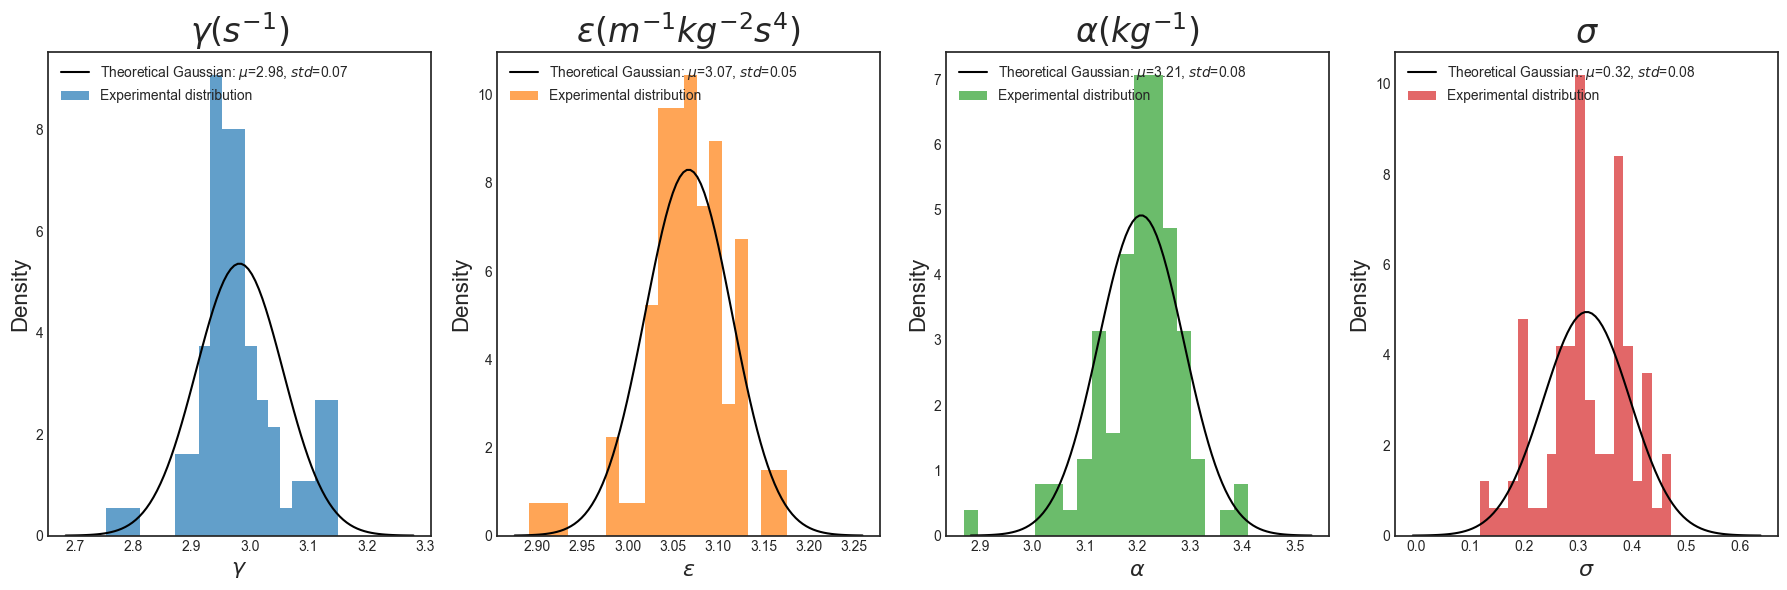

$\gamma (s^{-1})$
T-test results:  TtestResult(statistic=np.float64(-7.837978365428212), pvalue=np.float64(2.6472766555191224e-12), df=np.float64(114.0))
$\gamma (s^{-1})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.9461116453834518), pvalue=np.float64(0.0008359133467386145))
$\varepsilon (m^{-1} kg^{-2} s^{4})$
T-test results:  TtestResult(statistic=np.float64(-2.140181980010296), pvalue=np.float64(0.03447145072184372), df=np.float64(114.0))
$\varepsilon (m^{-1} kg^{-2} s^{4})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.969322915252983), pvalue=np.float64(0.028784304716648473))
$\alpha (kg^{-1})$
T-test results:  TtestResult(statistic=np.float64(-6.789701335657102), pvalue=np.float64(5.337356667867048e-10), df=np.float64(114.0))
$\alpha (kg^{-1})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.983019145846957), pvalue=np.float64(0.27660298051671567))
$\sigma$
T-test results:  TtestResult(statistic=np.float64(3.1188613448820877)

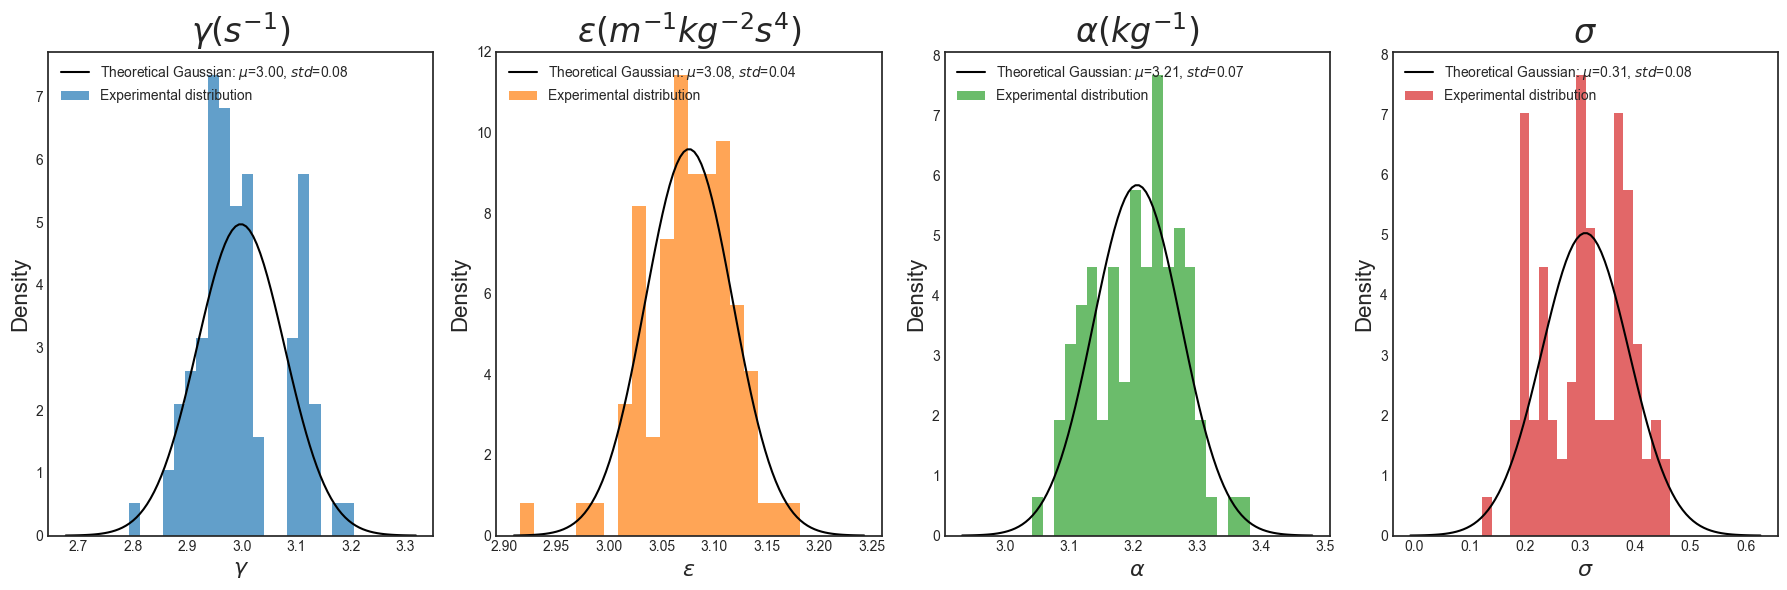

$\gamma (s^{-1})$
T-test results:  TtestResult(statistic=np.float64(-7.655866540696942), pvalue=np.float64(6.51157962779643e-12), df=np.float64(115.0))
$\gamma (s^{-1})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.8900974418291453), pvalue=np.float64(1.0713952555896674e-06))
$\varepsilon (m^{-1} kg^{-2} s^{4})$
T-test results:  TtestResult(statistic=np.float64(-2.3606553417648817), pvalue=np.float64(0.019925997390095356), df=np.float64(115.0))
$\varepsilon (m^{-1} kg^{-2} s^{4})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.9656900439016158), pvalue=np.float64(0.015109172867231886))
$\alpha (kg^{-1})$
T-test results:  TtestResult(statistic=np.float64(-8.649100439708958), pvalue=np.float64(3.584923854106351e-14), df=np.float64(115.0))
$\alpha (kg^{-1})$
Shapiro-Wilk test results: ShapiroResult(statistic=np.float64(0.8172176465365006), pvalue=np.float64(2.2665287642118476e-09))
$\sigma$
T-test results:  TtestResult(statistic=np.float64(3.03608812101

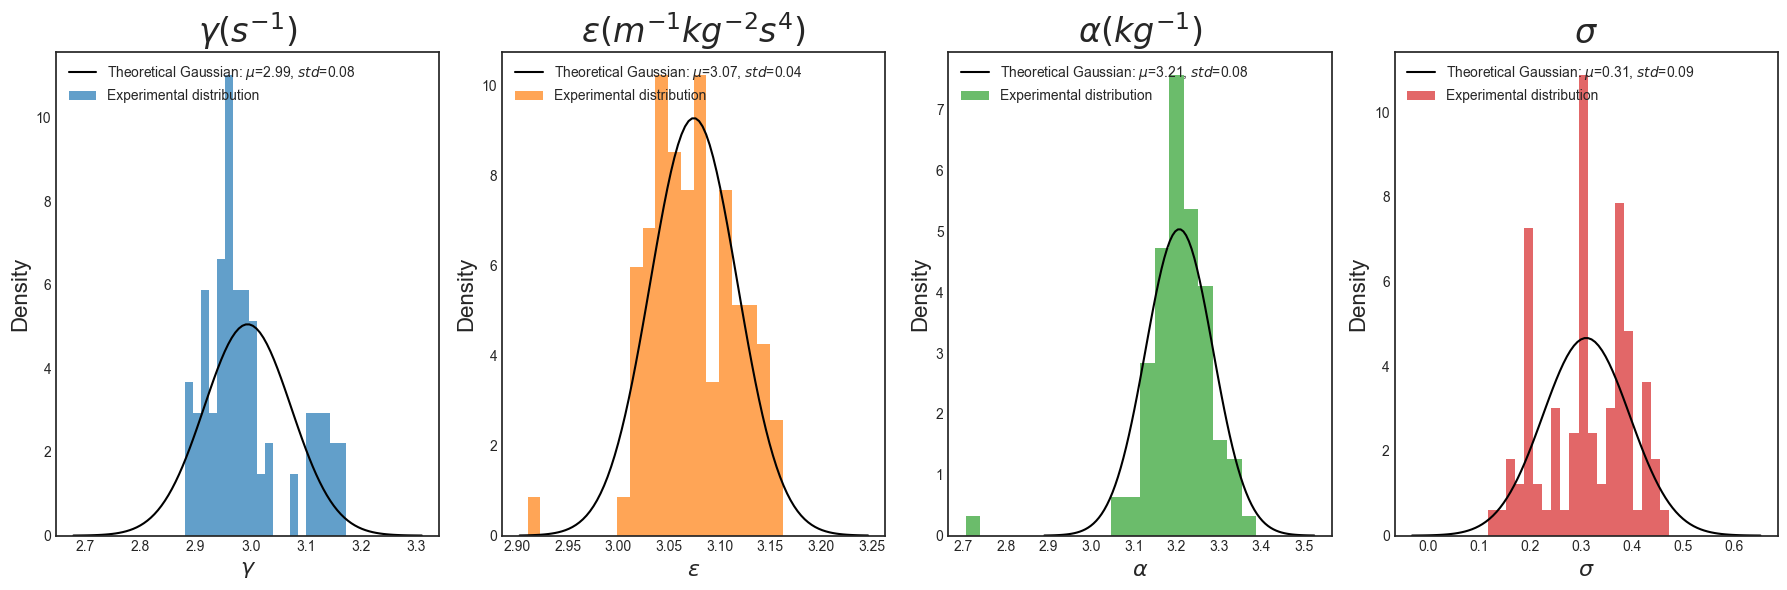

In [26]:
t_tests = []
sw_tests = []
means = []
devs = [] 
for motivation in range(1, 4): 
#subject = 25
    t_tests_, sw_tests_, means_, devs_ = plotting_dict_params(params_dict = new_params_motiv[motivation], opt_sigma = opt_sigma_motiv[motivation], 
                         barWidth=0.5, plotting_ = 1,
                         saving_plot = True, folder_name = 'fitted_pics', 
                         pic_name = f'parameters_gaussians_motiv_values_{motivation}')
    t_tests.append(t_tests_)
    sw_tests.append(sw_tests_)
    means.append(means_)
    devs.append(devs_)